In [1]:
%pip install torch torchvision torchaudio

INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 7.4 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 5.8 MB/s  0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.8.0
    Uninstalling torch-2.8.0:━━━━━━━━━━━━━━━━━━━ 0/3 [torch]
      Successfully uninstalled torch-2.8.0━━ 0/3 [torch]
  Attempting uninstall: torchaudiom━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torchvision]
    Found existing installation: torchaudio 2.8.0━━━━━━━━━━━━━ 1/3 [torchvision]
    Uninstalling torchaudio-2.8.0:0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torchvision]
      Successfully uninstalled torchaudio-2.8.0━━━━━━━━━━━━━━━ 1/3 [torchvision]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchaudio]m [torchvision]

[notice] A

In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

plt.ion()   # interactive mode

In [5]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '../data/hymenoptera_data'  #경로 수정
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# MPS > CPU 순서로 선택

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("Using CPU device")

print(f"Device: {device}")

Using MPS device (Apple Silicon)
Device: mps


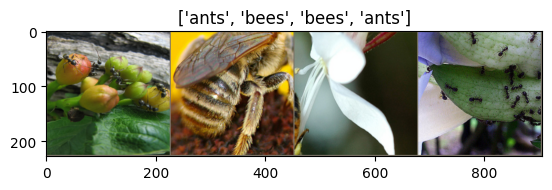

In [6]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]  # MPS는 double 미지원

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [13]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [14]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [15]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6061 Acc: 0.6844
val Loss: 0.2254 Acc: 0.9216

Epoch 1/24
----------
train Loss: 0.4566 Acc: 0.8115
val Loss: 0.2888 Acc: 0.8824

Epoch 2/24
----------
train Loss: 0.5024 Acc: 0.7746
val Loss: 0.3417 Acc: 0.9085

Epoch 3/24
----------
train Loss: 0.5837 Acc: 0.7705
val Loss: 0.2489 Acc: 0.8954

Epoch 4/24
----------
train Loss: 0.5125 Acc: 0.8115
val Loss: 0.5458 Acc: 0.8039

Epoch 5/24
----------
train Loss: 0.9217 Acc: 0.7172
val Loss: 1.0262 Acc: 0.7843

Epoch 6/24
----------
train Loss: 0.5438 Acc: 0.8156
val Loss: 0.4567 Acc: 0.8431

Epoch 7/24
----------
train Loss: 0.4025 Acc: 0.8197
val Loss: 0.3221 Acc: 0.8693

Epoch 8/24
----------
train Loss: 0.3574 Acc: 0.8443
val Loss: 0.2661 Acc: 0.9020

Epoch 9/24
----------
train Loss: 0.2951 Acc: 0.8566
val Loss: 0.2440 Acc: 0.8954

Epoch 10/24
----------
train Loss: 0.3184 Acc: 0.8566
val Loss: 0.2287 Acc: 0.9020

Epoch 11/24
----------
train Loss: 0.3981 Acc: 0.8238
val Loss: 0.2454 Acc: 0.9020

Ep

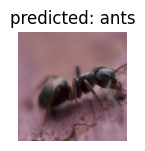

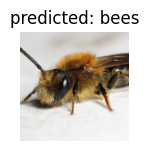

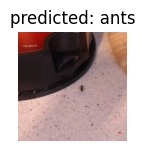

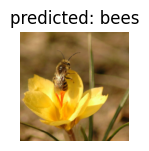

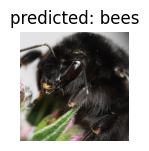

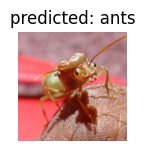

In [16]:
visualize_model(model_ft)

In [17]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [18]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6213 Acc: 0.6680
val Loss: 0.2763 Acc: 0.8889

Epoch 1/24
----------
train Loss: 0.6369 Acc: 0.7459
val Loss: 0.1999 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.5361 Acc: 0.7500
val Loss: 0.2073 Acc: 0.9281

Epoch 3/24
----------
train Loss: 0.5054 Acc: 0.8033
val Loss: 0.1843 Acc: 0.9216

Epoch 4/24
----------
train Loss: 0.5484 Acc: 0.7459
val Loss: 0.2750 Acc: 0.8889

Epoch 5/24
----------
train Loss: 0.4328 Acc: 0.8238
val Loss: 0.1814 Acc: 0.9477

Epoch 6/24
----------
train Loss: 0.6743 Acc: 0.7336
val Loss: 0.4165 Acc: 0.8497

Epoch 7/24
----------
train Loss: 0.3668 Acc: 0.8443
val Loss: 0.1944 Acc: 0.9281

Epoch 8/24
----------
train Loss: 0.3051 Acc: 0.8811
val Loss: 0.1803 Acc: 0.9346

Epoch 9/24
----------
train Loss: 0.3345 Acc: 0.8525
val Loss: 0.2006 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3373 Acc: 0.8607
val Loss: 0.2073 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3184 Acc: 0.8402
val Loss: 0.1956 Acc: 0.9346

Ep

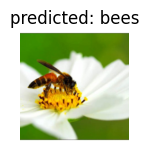

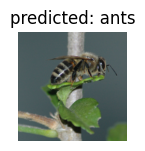

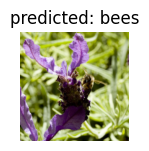

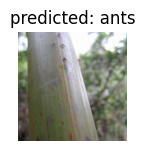

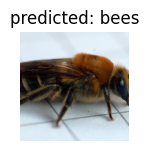

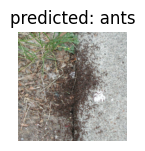

In [19]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [20]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

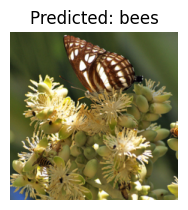

In [21]:
visualize_model_predictions(
    model_conv,
    img_path='../data/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

# 고양이/개 분류 (Cats vs Dogs Classification)

이 섹션에서는 고양이와 개 이미지를 분류하는 모델을 학습합니다.

## 1. 데이터셋 준비 및 시각화
## 2. 모델 학습
## 3. 예측 결과 시각화


In [23]:
# 고양이/개 데이터셋 로드
cats_dogs_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 추가 데이터 증강
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

cats_dogs_dir = '../data/sample_computer_vision'
cats_dogs_datasets = {x: datasets.ImageFolder(os.path.join(cats_dogs_dir, x),
                                               cats_dogs_transforms[x])
                      for x in ['train', 'val']}
cats_dogs_loaders = {x: torch.utils.data.DataLoader(cats_dogs_datasets[x], batch_size=32,
                                                     shuffle=True, num_workers=4)
                     for x in ['train', 'val']}
cats_dogs_sizes = {x: len(cats_dogs_datasets[x]) for x in ['train', 'val']}
cats_dogs_classes = cats_dogs_datasets['train'].classes

print(f"✅ 데이터셋 로드 완료!")
print(f"📊 클래스: {cats_dogs_classes}")
print(f"📦 학습 데이터: {cats_dogs_sizes['train']}개")
print(f"📦 검증 데이터: {cats_dogs_sizes['val']}개")


✅ 데이터셋 로드 완료!
📊 클래스: ['cats', 'dogs']
📦 학습 데이터: 1002개
📦 검증 데이터: 200개


📸 학습 데이터 샘플:


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10ec74cc0>
Traceback (most recent call last):
  File "/Users/songdongseon/AI/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/Users/songdongseon/AI/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1618, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/popen_fork.py", line 41, in wait
    if not wait([self.sentinel], timeout):
  File "/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/connection.py", line 1148, in wait
    

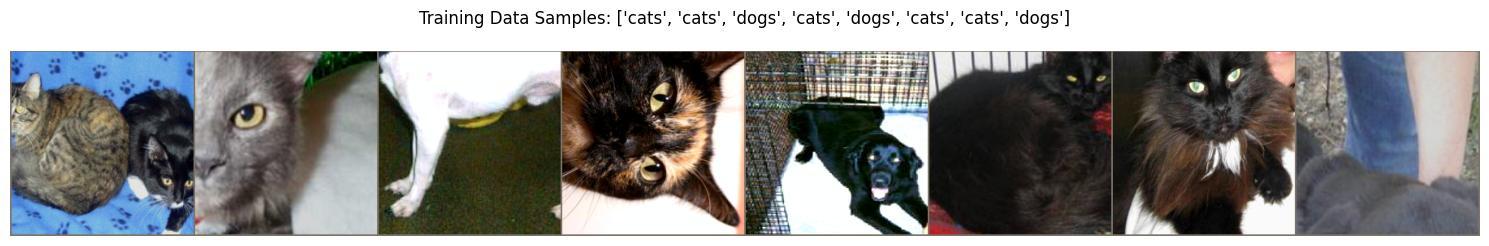

In [24]:
# 1. 데이터셋 시각화 - 학습 데이터 샘플 보기
def show_cats_dogs_samples(dataloader, class_names, num_samples=8):
    """고양이/개 데이터셋 샘플 시각화"""
    inputs, classes = next(iter(dataloader))
    
    # 그리드로 이미지 생성
    out = torchvision.utils.make_grid(inputs[:num_samples])
    
    # 역정규화
    inp = out.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(15, 8))
    plt.imshow(inp)
    plt.title(f'Training Data Samples: {[class_names[x] for x in classes[:num_samples]]}', 
              fontsize=12, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("📸 학습 데이터 샘플:")
show_cats_dogs_samples(cats_dogs_loaders['train'], cats_dogs_classes, num_samples=8)


In [25]:
# 2. 고양이/개 분류 모델 정의 (Transfer Learning with ResNet18)
print("🔧 모델 준비 중...")

# ResNet18 사전학습 모델 로드
cats_dogs_model = models.resnet18(weights='IMAGENET1K_V1')

# 마지막 FC 레이어를 2개 클래스(cats, dogs)로 변경
num_features = cats_dogs_model.fc.in_features
cats_dogs_model.fc = nn.Linear(num_features, 2)

# MPS 디바이스로 이동
cats_dogs_model = cats_dogs_model.to(device)

# 손실 함수 및 옵티마이저
cats_dogs_criterion = nn.CrossEntropyLoss()
cats_dogs_optimizer = optim.SGD(cats_dogs_model.parameters(), lr=0.001, momentum=0.9)

# 학습률 스케줄러
cats_dogs_scheduler = lr_scheduler.StepLR(cats_dogs_optimizer, step_size=7, gamma=0.1)

print(f"✅ 모델 준비 완료! (Device: {device})")
print(f"📊 출력 클래스 수: 2 (cats, dogs)")


🔧 모델 준비 중...
✅ 모델 준비 완료! (Device: mps)
📊 출력 클래스 수: 2 (cats, dogs)


In [27]:
# 고양이/개 데이터셋용 학습 함수
def train_cats_dogs_model(model, criterion, optimizer, scheduler, num_epochs=15):
    """고양이/개 분류 모델 학습"""
    since = time.time()
    
    # 학습 히스토리 저장
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_cats_dogs_model.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        
        for epoch in range(num_epochs):
            print(f'\n{"="*60}')
            print(f'Epoch {epoch+1}/{num_epochs}')
            print(f'{"="*60}')
            
            # 각 에포크는 train과 validation 단계를 가짐
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()
                
                running_loss = 0.0
                running_corrects = 0
                
                # 데이터 반복
                for inputs, labels in cats_dogs_loaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    
                    # forward
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        
                        # backward + optimize (학습 단계에서만)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    
                    # 통계
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                
                if phase == 'train':
                    scheduler.step()
                
                epoch_loss = running_loss / cats_dogs_sizes[phase]
                epoch_acc = running_corrects.float() / cats_dogs_sizes[phase]
                
                # 히스토리 저장
                if phase == 'train':
                    history['train_loss'].append(epoch_loss)
                    history['train_acc'].append(epoch_acc.item())
                else:
                    history['val_loss'].append(epoch_loss)
                    history['val_acc'].append(epoch_acc.item())
                
                print(f'{phase:5s} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
                
                # 최고 모델 저장
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
                    print(f'✨ New best model saved! (Acc: {best_acc:.4f})')
        
        time_elapsed = time.time() - since
        print(f'\n{"="*60}')
        print(f'🎉 학습 완료!')
        print(f'⏱️  소요 시간: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'🏆 최고 검증 정확도: {best_acc:.4f}')
        print(f'{"="*60}')
        
        # 최고 모델 로드
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    
    return model, history


In [28]:
# 3. 모델 학습 실행 (15 에포크)
print("🚀 학습 시작!\n")

cats_dogs_model, training_history = train_cats_dogs_model(
    cats_dogs_model, 
    cats_dogs_criterion, 
    cats_dogs_optimizer, 
    cats_dogs_scheduler,
    num_epochs=15
)


🚀 학습 시작!


Epoch 1/15
train | Loss: 0.4311 | Acc: 0.7784
val   | Loss: 0.1492 | Acc: 0.9450
✨ New best model saved! (Acc: 0.9450)

Epoch 2/15
train | Loss: 0.1807 | Acc: 0.9341
val   | Loss: 0.1024 | Acc: 0.9750
✨ New best model saved! (Acc: 0.9750)

Epoch 3/15
train | Loss: 0.1588 | Acc: 0.9441
val   | Loss: 0.1092 | Acc: 0.9700

Epoch 4/15
train | Loss: 0.1355 | Acc: 0.9461
val   | Loss: 0.0909 | Acc: 0.9750

Epoch 5/15
train | Loss: 0.1423 | Acc: 0.9431
val   | Loss: 0.0950 | Acc: 0.9750

Epoch 6/15
train | Loss: 0.1148 | Acc: 0.9551
val   | Loss: 0.1137 | Acc: 0.9700

Epoch 7/15
train | Loss: 0.0944 | Acc: 0.9621
val   | Loss: 0.1217 | Acc: 0.9550

Epoch 8/15
train | Loss: 0.0963 | Acc: 0.9611
val   | Loss: 0.1071 | Acc: 0.9750

Epoch 9/15
train | Loss: 0.1176 | Acc: 0.9461
val   | Loss: 0.1045 | Acc: 0.9800
✨ New best model saved! (Acc: 0.9800)

Epoch 10/15
train | Loss: 0.1145 | Acc: 0.9511
val   | Loss: 0.1200 | Acc: 0.9550

Epoch 11/15
train | Loss: 0.0931 | Acc: 0.9621
val   |

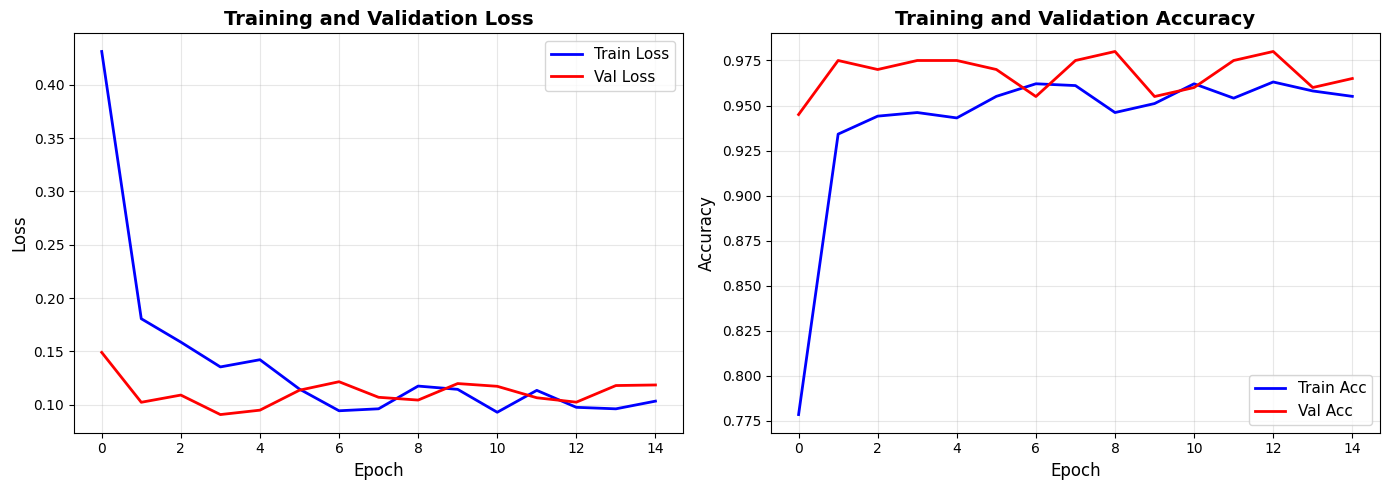


📊 최종 학습 결과:
✓ 최종 학습 정확도: 0.9551
✓ 최종 검증 정확도: 0.9650
✓ 최고 검증 정확도: 0.9800


In [29]:
# 4. 학습 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(training_history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy 그래프
axes[1].plot(training_history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(training_history['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 결과 출력
print("\n📊 최종 학습 결과:")
print(f"✓ 최종 학습 정확도: {training_history['train_acc'][-1]:.4f}")
print(f"✓ 최종 검증 정확도: {training_history['val_acc'][-1]:.4f}")
print(f"✓ 최고 검증 정확도: {max(training_history['val_acc']):.4f}")


In [30]:
# 5. 예측 결과 시각화 함수
def visualize_cats_dogs_predictions(model, num_images=8):
    """검증 데이터에서 예측 결과 시각화"""
    was_training = model.training
    model.eval()
    
    images_so_far = 0
    fig = plt.figure(figsize=(16, 10))
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(cats_dogs_loaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(2, 4, images_so_far)
                ax.axis('off')
                
                # 정답 여부 확인
                true_label = cats_dogs_classes[labels[j]]
                pred_label = cats_dogs_classes[preds[j]]
                is_correct = labels[j] == preds[j]
                
                # 색상 설정 (정답: 초록, 오답: 빨강)
                color = 'green' if is_correct else 'red'
                title = f'Pred: {pred_label}\nTrue: {true_label}'
                
                ax.set_title(title, color=color, fontsize=11, fontweight='bold')
                
                # 이미지 표시
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                ax.imshow(img)
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    return
    
    model.train(mode=was_training)
    plt.tight_layout()


🔍 예측 결과 시각화 (초록색: 정답, 빨간색: 오답)



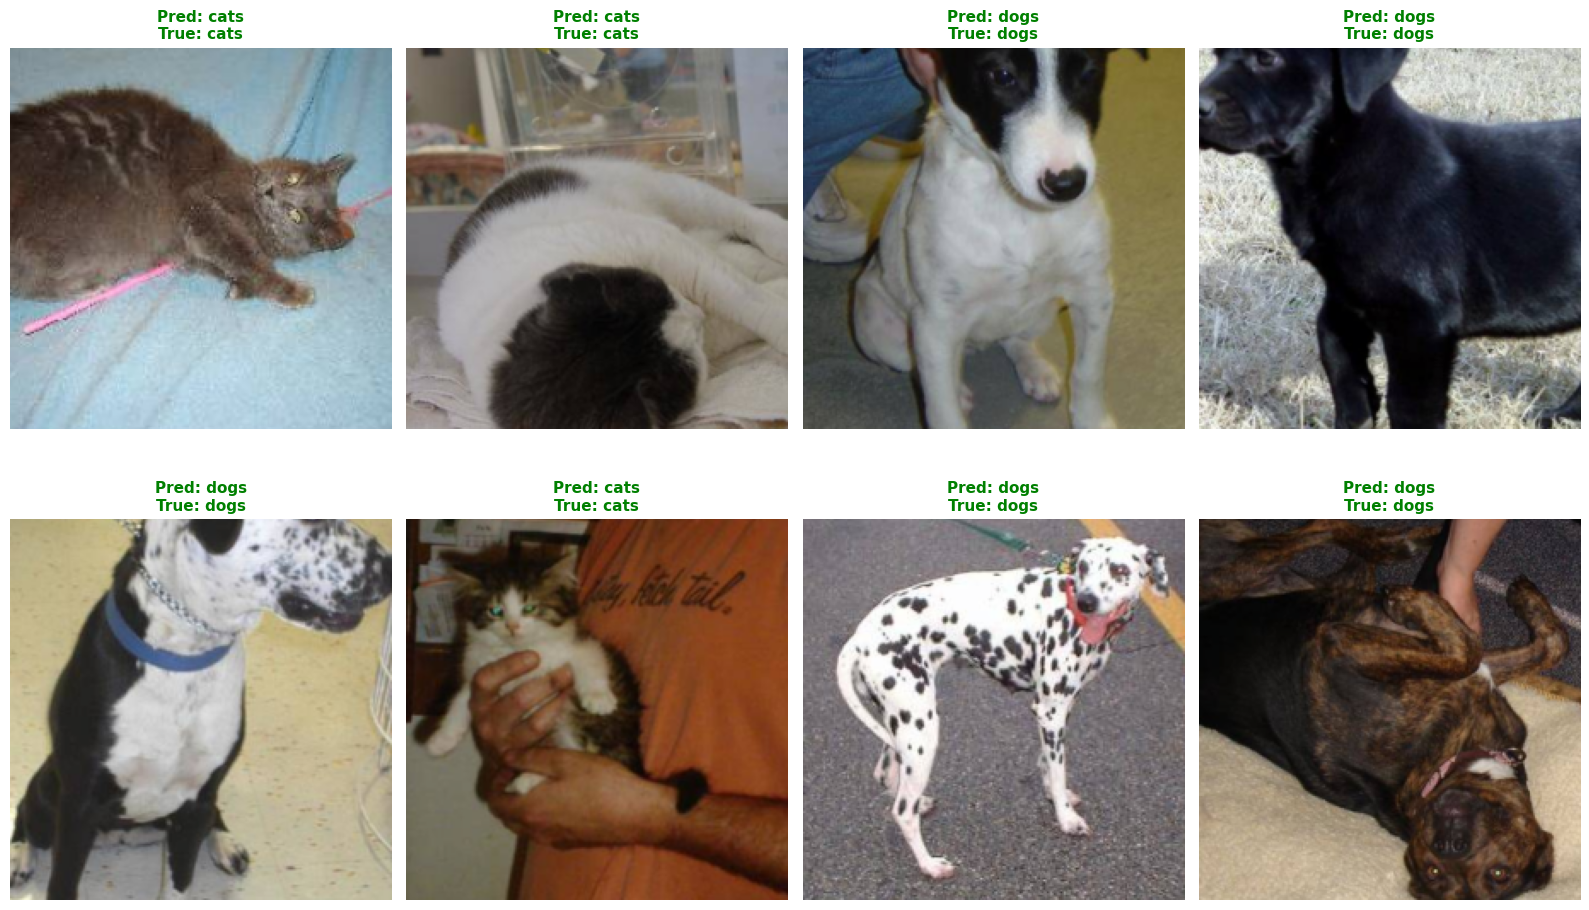

In [31]:
# 6. 예측 결과 시각화 (8장)
print("🔍 예측 결과 시각화 (초록색: 정답, 빨간색: 오답)\n")
visualize_cats_dogs_predictions(cats_dogs_model, num_images=8)
plt.show()


In [32]:
# 7. 검증 데이터셋 전체 평가
def evaluate_model(model, dataloader, dataset_size):
    """모델 평가 및 상세 통계 출력"""
    model.eval()
    
    all_preds = []
    all_labels = []
    correct_cats = 0
    correct_dogs = 0
    total_cats = 0
    total_dogs = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # 클래스별 정확도 계산
            for i in range(len(labels)):
                if labels[i] == 0:  # cats
                    total_cats += 1
                    if preds[i] == labels[i]:
                        correct_cats += 1
                else:  # dogs
                    total_dogs += 1
                    if preds[i] == labels[i]:
                        correct_dogs += 1
    
    # 전체 정확도
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall_acc = (all_preds == all_labels).sum() / len(all_labels)
    
    # 클래스별 정확도
    cats_acc = correct_cats / total_cats if total_cats > 0 else 0
    dogs_acc = correct_dogs / total_dogs if total_dogs > 0 else 0
    
    print("\n" + "="*60)
    print("📊 최종 평가 결과 (Validation Set)")
    print("="*60)
    print(f"전체 정확도: {overall_acc:.4f} ({(all_preds == all_labels).sum()}/{len(all_labels)})")
    print(f"\n클래스별 정확도:")
    print(f"  🐱 Cats: {cats_acc:.4f} ({correct_cats}/{total_cats})")
    print(f"  🐶 Dogs: {dogs_acc:.4f} ({correct_dogs}/{total_dogs})")
    print("="*60)
    
    return all_preds, all_labels

# 평가 실행
predictions, true_labels = evaluate_model(cats_dogs_model, cats_dogs_loaders['val'], cats_dogs_sizes['val'])



📊 최종 평가 결과 (Validation Set)
전체 정확도: 0.9800 (196/200)

클래스별 정확도:
  🐱 Cats: 0.9800 (98/100)
  🐶 Dogs: 0.9800 (98/100)


In [35]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


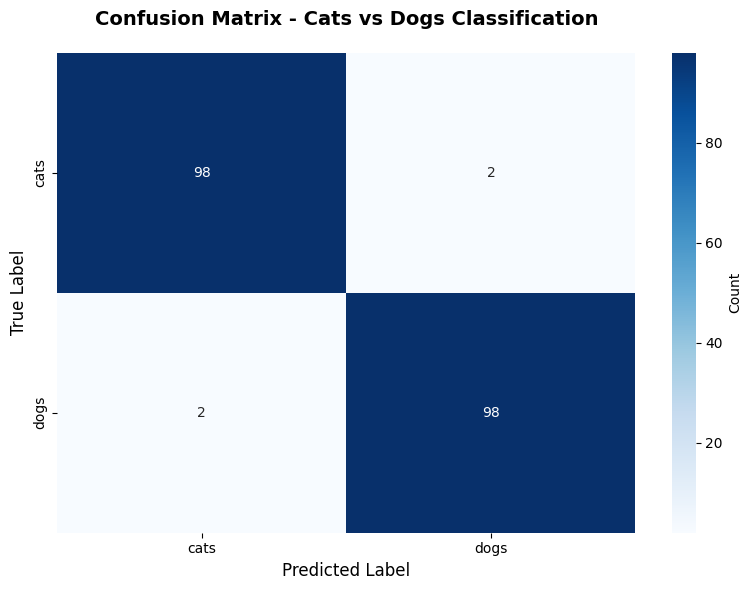


모든 분석 완료!


In [36]:
# 8. 혼동 행렬 (Confusion Matrix) 시각화
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 혼동 행렬 계산
cm = confusion_matrix(true_labels, predictions)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cats_dogs_classes, 
            yticklabels=cats_dogs_classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Cats vs Dogs Classification', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n모든 분석 완료!")
